# MCQMC 2026 Plenary Talk Running Example

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vf}{\boldsymbol{f}}
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vu}{\boldsymbol{u}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vy}{\boldsymbol{y}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vmu}{\boldsymbol{\mu}}
\newcommand{\mSigma}{\mathsf{\Sigma}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\Norm}{\operatorname{Norm}}
\newcommand{\GP}{\operatorname{GP}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

We observe noisy function values

$$
Y_i = f(x_i) + \epsilon_i, \qquad 
\epsilon_i \sim \Norm(0,\sigma^2),
\qquad i=1,\ldots,m,
$$

and place a Gaussian process prior on the unknown function,

$$
f \sim \GP(0,K_\theta).
$$

Because the prior and likelihood are Gaussian, the posterior distribution of the latent function values on a grid,

$$
\vf =
\bigl(f(t_1),\ldots,f(t_d)\bigr)^\top,
$$

is multivariate normal,

$$
\vf \mid \vy
\sim
\Norm(\vmu,\mSigma).
$$

The quantity of interest is the posterior probability that the latent function remains below a safety threshold $c$ on the grid:

$$
p
=
\Pr\{ f(t_j) \le c,\ j=1,\ldots,d \mid \vy \}
=
\int_{\mathbb{R}^d}
\mathbf{1}\{\vz \le c\mathbf{1}\}
\,
\phi_d(\vz;\vmu,\mSigma)
\,\dif \vz.
$$

After a transformation from independent uniforms to the posterior Gaussian vector, this becomes an integral over the unit cube,

$$
p
=
\int_{[0,1]^d}
g(\vu)\,\dif \vu.
$$

This single example lets us compare Monte Carlo and quasi-Monte Carlo sampling, study the effect of variable transformations, test randomized error estimation, and later consider refinements such as multilevel or dimension-reduction strategies.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import qmcpy as qp
import time
from IPython.display import display, Markdown

import classlib as cl
import classlib.nbviz as nb

%matplotlib inline

rng = np.random.default_rng(20260527)

nb.init(use_tex=True)
colors = nb.TOL_BRIGHT
nb.configure(
    figpath="MCQMC26_figures",
    savefigs=True,
    imgfrmt="png",
)
# nb.SAVEFIGS = False

## Notebook parameters

In [59]:
rng_seed = 20260527

n_obs = 39 #number of observations of the function
d_grid = 64 #number of evaluation points along the line

sigma_noise = 0.15
jitter = 1e-10

threshold = 0.20

In [64]:
# Synthetic data and Gaussian process posterior

rng = np.random.default_rng(rng_seed)

def f_true(x):
    return (
        -0.4
        + 0.1 * np.cos(2 * np.pi*x)
        + 0.35 * np.sin(2 * np.pi * x)
        + 0.22 * np.cos(6 * np.pi * x)
        + 0.12 * np.sin(10 * np.pi * x)
    )

def sqexp_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    return amp**2 * np.exp(-0.5 * ((x - z) / ell)**2)

def matern52_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt5r = np.sqrt(5) * r
    return amp**2 * (1 + sqrt5r + 5 * r**2 / 3) * np.exp(-sqrt5r)

def matern32_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt3r = np.sqrt(3) * r
    return amp**2 * (1 + sqrt3r) * np.exp(-sqrt3r)

kernel = matern32_kernel

x_obs = np.linspace(0.08, 0.92, n_obs)
y_obs = f_true(x_obs) + sigma_noise * rng.standard_normal(n_obs)

t_grid = np.linspace(0.02, 0.98, d_grid)

K_xx = kernel(x_obs, x_obs, amp=amp, ell=ell)
K_tx = kernel(t_grid, x_obs, amp=amp, ell=ell)
K_tt = kernel(t_grid, t_grid, amp=amp, ell=ell)

A = K_xx + sigma_noise**2 * np.eye(n_obs)
L_A = np.linalg.cholesky(A + jitter * np.eye(n_obs))

alpha = np.linalg.solve(L_A.T, np.linalg.solve(L_A, y_obs))
post_mean = K_tx @ alpha

V = np.linalg.solve(L_A, K_tx.T)
post_cov = K_tt - V.T @ V
post_cov = 0.5 * (post_cov + post_cov.T)

L_post = np.linalg.cholesky(post_cov + jitter * np.eye(d_grid))

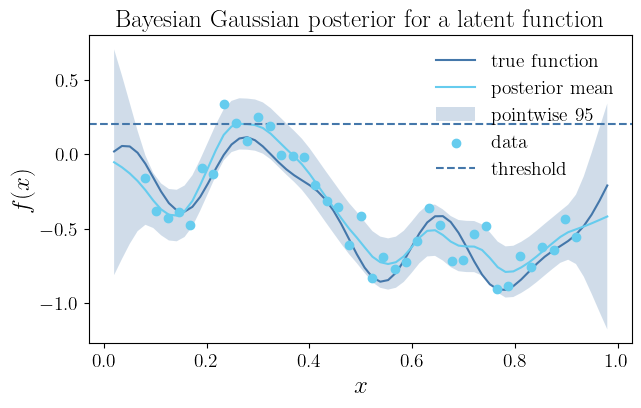

In [65]:
# Plot posterior mean and pointwise credible band

post_sd = np.sqrt(np.diag(post_cov))

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(t_grid, f_true(t_grid), label="true function")
ax.plot(t_grid, post_mean, label="posterior mean")
ax.fill_between(
    t_grid,
    post_mean - 1.96 * post_sd,
    post_mean + 1.96 * post_sd,
    alpha=0.25,
    label="pointwise 95% band",
)
ax.scatter(x_obs, y_obs, zorder=5, label="data")
ax.axhline(threshold, linestyle="--", label="threshold")

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Bayesian Gaussian posterior for a latent function")
ax.legend(loc="best")

if nb.SAVEFIGS:
    nb.savefig("posterior_gp_example")
plt.show()

In [66]:
# Quantity of interest: posterior probability that the curve stays below the threshold

def direct_integrand(u):
    u = np.asarray(u)
    z = stats.norm.ppf(u)
    f_samples = post_mean + z @ L_post.T
    return np.all(f_samples <= threshold, axis=1).astype(float)

def estimate_integral(u):
    vals = direct_integrand(u)
    return vals.mean(), vals.std(ddof=1) / math.sqrt(len(vals))

In [67]:
# First crude Monte Carlo check

n = 2**12
u_mc = rng.random((n, d_grid))

p_hat, se_hat = estimate_integral(u_mc)

print(f"n = {n}")
print(f"estimated probability = {p_hat:.5f}")
print(f"Monte Carlo standard error = {se_hat:.5f}")

n = 4096
estimated probability = 0.14624
Monte Carlo standard error = 0.00552


In [68]:
# Sobol' check, direct inverse-normal transform

n = 2**12

sobol = stats.qmc.Sobol(d=d_grid, scramble=True, seed=rng_seed)
u_sobol = sobol.random(n)

p_hat_sobol, se_naive_sobol = estimate_integral(u_sobol)

print(f"n = {n}")
print(f"Sobol' estimate = {p_hat_sobol:.5f}")
print(f"naive standard error, not valid for QMC = {se_naive_sobol:.5f}")

n = 4096
Sobol' estimate = 0.15698
naive standard error, not valid for QMC = 0.00568


In [69]:
# Randomized replicate comparison: MC versus scrambled Sobol'

def mc_replicates(n, r, seed=12345):
    rng_local = np.random.default_rng(seed)
    estimates = np.empty(r)
    for k in range(r):
        u = rng_local.random((n, d_grid))
        estimates[k] = direct_integrand(u).mean()
    return estimates

def sobol_replicates(n, r, seed=12345):
    estimates = np.empty(r)
    for k in range(r):
        sobol = stats.qmc.Sobol(d=d_grid, scramble=True, seed=seed + k)
        u = sobol.random(n)
        estimates[k] = direct_integrand(u).mean()
    return estimates

n = 2**10
r = 64

est_mc = mc_replicates(n, r)
est_sobol = sobol_replicates(n, r)

summary = {
    "MC mean": est_mc.mean(),
    "MC sd": est_mc.std(ddof=1),
    "Sobol mean": est_sobol.mean(),
    "Sobol sd": est_sobol.std(ddof=1),
    "sd ratio MC/Sobol": est_mc.std(ddof=1) / est_sobol.std(ddof=1),
}

summary

{'MC mean': np.float64(0.1546173095703125),
 'MC sd': np.float64(0.012008466488283461),
 'Sobol mean': np.float64(0.1534423828125),
 'Sobol sd': np.float64(0.007409749846478516),
 'sd ratio MC/Sobol': np.float64(1.620630485115565)}

In [ ]:
# Plot randomized estimates

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(est_mc, "o", label="MC")
ax.plot(est_sobol, "o", label="Scrambled Sobol'")
ax.axhline(est_mc.mean(), linestyle=":", label="MC mean")
ax.axhline(est_sobol.mean(), linestyle="--", label="Sobol' mean")

ax.set_xlabel("randomization")
ax.set_ylabel("estimated probability")
ax.set_title(f"Randomized estimates, n = {n:,}")
ax.legend(loc="best")

cl.nbviz.savefig(fig, "mc_vs_sobol_randomized_estimates")
plt.show()